In [4]:
import sys 
!"{sys.executable}" -m pip install networkx numpy scipy torch scikit-learn matplotlib
# torch-geometric may require special install steps on Windows and is optional for this notebook



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


C:\Users\ALBIN JOHN\AppData\Local\Temp\ipykernel_31016\4042229171.py:13: UserWarning: Input line 504 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  edges_str = np.loadtxt(path, dtype=str, usecols=(0, 1))


Nodes: 65
Edges: 503


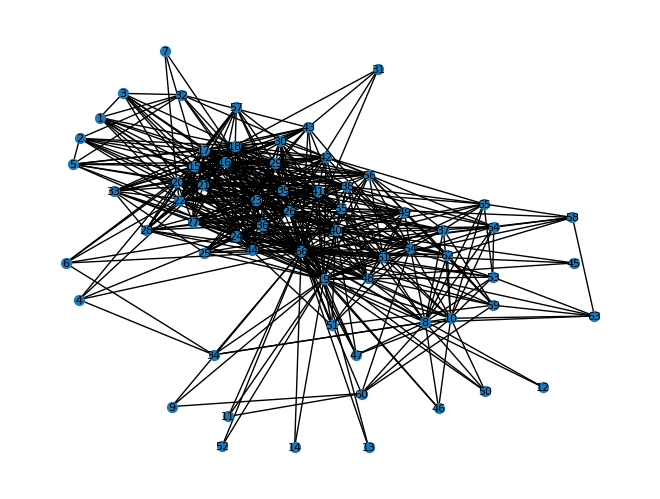

In [6]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Create empty graph
G = nx.Graph()

# Load cypedge edgelist as an unweighted graph
path = os.path.join("..", "Datasets", "cypedge.txt") 

# Load columns 0 and 1 as strings to handle the 'V' prefix safely
edges_str = np.loadtxt(path, dtype=str, usecols=(0, 1))

# Strip the 'V' prefix from each node label and convert to an integer
edges = np.array([[int(node.replace('V', '')) for node in row] for row in edges_str])

# If the file has a single edge, np.loadtxt returns a 1D array, so normalize it.
if edges.ndim == 1:
    edges = edges.reshape(1, 2)

G.add_edges_from(edges)

# Basic info
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Draw graph only if it is reasonably small; otherwise skip plotting.
if G.number_of_nodes() <= 200:
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=50, font_size=8)
    plt.show()
else:
    print("Graph is large; skipping full plot.")


In [7]:
# adjacency matrix
nodelist = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodelist)
print(A)

[[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [8]:
#Degree
deg = np.array([G.degree(n) for n in nodelist])
deg

array([10,  9, 26, 25, 26, 28, 29, 31, 20,  9, 64, 10, 10,  5, 28,  6,  6,
        3, 17, 45, 13,  4,  6, 17,  4,  9, 18, 23,  7, 20, 12,  6, 11, 11,
        3, 17,  3,  2,  2,  2, 27, 33, 19, 14, 20, 18, 13, 22, 23, 20, 29,
       24, 20, 15, 21, 18, 11,  4, 13,  3, 15,  8,  2, 10,  7])

In [9]:
dist = dict(nx.all_pairs_shortest_path_length(G))
dist

{np.int64(1): {np.int64(1): 0,
  np.int64(3): 1,
  np.int64(15): 1,
  np.int64(16): 1,
  np.int64(17): 1,
  np.int64(18): 1,
  np.int64(20): 1,
  np.int64(21): 1,
  np.int64(22): 1,
  np.int64(32): 1,
  np.int64(66): 1,
  np.int64(2): 2,
  np.int64(5): 2,
  np.int64(6): 2,
  np.int64(23): 2,
  np.int64(24): 2,
  np.int64(26): 2,
  np.int64(27): 2,
  np.int64(28): 2,
  np.int64(29): 2,
  np.int64(30): 2,
  np.int64(33): 2,
  np.int64(36): 2,
  np.int64(38): 2,
  np.int64(39): 2,
  np.int64(40): 2,
  np.int64(41): 2,
  np.int64(42): 2,
  np.int64(43): 2,
  np.int64(44): 2,
  np.int64(55): 2,
  np.int64(56): 2,
  np.int64(57): 2,
  np.int64(31): 2,
  np.int64(4): 2,
  np.int64(7): 2,
  np.int64(19): 2,
  np.int64(8): 2,
  np.int64(9): 2,
  np.int64(10): 2,
  np.int64(11): 2,
  np.int64(12): 2,
  np.int64(13): 2,
  np.int64(14): 2,
  np.int64(25): 2,
  np.int64(34): 2,
  np.int64(37): 2,
  np.int64(45): 2,
  np.int64(46): 2,
  np.int64(47): 2,
  np.int64(48): 2,
  np.int64(49): 2,
  np.int

In [10]:
n = len(nodelist)
dist_matrix = np.zeros((n, n))

for i, u in enumerate(nodelist):
    for j, v in enumerate(nodelist):
        if i != j and v in dist[u]:
            dist_matrix[i, j] = dist[u][v]

print(dist_matrix)

[[0. 1. 1. ... 2. 2. 2.]
 [1. 0. 1. ... 2. 2. 2.]
 [1. 1. 0. ... 2. 2. 2.]
 ...
 [2. 2. 2. ... 0. 2. 2.]
 [2. 2. 2. ... 2. 0. 2.]
 [2. 2. 2. ... 2. 2. 0.]]


4. Node Feature Extraction (Exact Formulas)

Paper defines three measures.

NLI  = Local influence

NGI  = Global influence

NLGC = Hybrid influence

### 4.1 Global Influence (NGI)

**Paper formula:**

$$\text{NGI}_i = \sum_{i \neq j} \frac{\sqrt{d(v_j) + \alpha}}{d_{ij}}$$

**Where:**
*   $d(v_j)$ = degree of node $j$
*   $d_{ij}$ = shortest path distance between node $i$ and node $j$
*   $\alpha$ = constant parameter

### 🔹 Node Global Influence (NGI) – Description

**Definition:**
NGI is a metric used to measure the overall importance of a node by considering its interaction with all other nodes in the network.

**Core Idea:**
It combines both:
*   **Local information** → node degree
*   **Global information** → shortest path distance

**Computation:**
For each node, influence is calculated by summing contributions from all other nodes based on:
*   **Smoothed degree** of the contributing node (using square root scaling)
*   **Distance** between the two nodes

**Role of Degree ($d(v_j)$):**
Nodes with higher connections contribute more influence. However, instead of using the raw degree directly, a square root transformation is applied to moderate the dominance of high-degree nodes.

**Role of Distance ($d_{ij}$):**
Influence decreases as distance increases, ensuring closer nodes have stronger impact. The inverse relationship gives higher weight to nearby nodes.

**Role of $\alpha$ (alpha):**
*   Added inside the square root to stabilize the computation.
*   Prevents zero or very small degree values from reducing influence too much.
*   Helps in smoothing the contribution of nodes.
*   $\alpha = 0.5$ provides a balanced contribution.

**Key Advantage:**
NGI captures both local connectivity and global positioning while ensuring balanced influence using square root scaling.

**Interpretation:**
A node with a higher NGI value is more influential in the network, considering both its connectivity and its position relative to other nodes.

In [11]:
alpha = 0.5

NGI = np.zeros(n)

for i, u in enumerate(nodelist):
    for j, v in enumerate(nodelist):
        if i != j and dist_matrix[i, j] != 0:
            NGI[i] += np.sqrt(deg[j] + alpha) / dist_matrix[i, j]

print("NGI:", NGI)

NGI: [145.8897726  143.78408966 177.28575735 177.02915951 178.81724552
 182.49823878 183.68575745 188.60344538 170.39720048 140.90889058
 236.53763251 145.96885427 146.37427755 134.59336412 184.21481489
 135.02859392 137.06512072 130.88652927 152.3630015  205.8568591
 151.94047631 132.79532981 138.19088945 162.32289132 132.79532981
 142.54403514 160.72252025 175.10486399 134.75559438 167.15430676
 148.45786288 133.73914578 146.78618976 146.78618976 130.1065819
 152.3630015  130.1065819  128.88212043 128.88212043 128.88212043
 185.3471185  194.26700321 170.1832311  158.09969705 170.69331126
 166.06433168 153.72856814 174.78486662 175.29614825 170.41047492
 186.03158268 178.41046334 168.90548012 156.99581674 172.68758893
 165.16760595 150.51928027 132.77107604 153.98938739 131.45297062
 158.38588738 142.52848856 128.88212043 140.86108343 136.0520721 ]


### 4.2 Node Local Influence (NLI)

**Formula:**

$$NLI_i = \frac{d(v_i) \times \log_2 \left( \sum_{j \in N_i} e^{d(v_j)} \right)}{n}$$

---

### 🔹 Node Local Influence (NLI) – Description

**Definition:**
NLI is a metric used to measure the importance of a node based on its local neighborhood structure, focusing only on its immediate connections.

**Core Idea:**
It captures influence using:
*   **Node’s own degree**
*   **Contribution from its neighboring nodes**

**Computation:**
For each node, influence is calculated by:
1. Taking the degree of the node.
2. Multiplying it with the logarithm of the sum of exponential contributions from its neighbors.
3. Normalizing by the total number of nodes ($n$).

**Role of Degree ($d(v_i)$):**
The degree reflects direct connectivity; nodes with more neighbors have higher local influence.

**Role of Neighbor Contribution:**
Each neighbor contributes via an exponential function, which:
*   Amplifies the importance of highly connected neighbors.
*   Highlights strong local structures.

**Role of Logarithm ($\\log$):**
*   Compresses large values from exponential growth.
*   Prevents numerical explosion and ensures balanced scaling.

**Role of Normalization ($n$):**
Dividing by total nodes ensures values are comparable across different graph sizes.

**Key Advantage:**
NLI focuses purely on local structure, making it effective in identifying nodes that are well-connected locally and surrounded by influential neighbors.

**Interpretation:**
A node with higher NLI is more influential within its immediate neighborhood, even if it is not globally central.

In [12]:
NLI = np.zeros(n)

for i, u in enumerate(nodelist):

    neighbors = list(G.neighbors(u))

    # Sum of exponential terms (using neighbor count here as influence proxy)
    exp_sum = 0
    for v in neighbors:
        exp_sum += np.exp(G.degree(v))   # you can modify this part if Ne_i(v_i) defined differently

    if exp_sum > 0:
        NLI[i] = (G.degree(u) * np.log2(exp_sum)) / n
    else:
        NLI[i] = 0

print("NLI:", NLI)

#calculation Verified

NLI: [14.20499733 12.78449759 36.93299305 35.51249331 36.93299305 39.77399251
 41.19449225 44.03549171 28.40999465 12.78449759 63.92249835 14.20499733
 14.20499733  7.10249866 39.77399252  8.5229984   8.5229984   4.2614992
 24.14849546 63.92248797 18.46649652  5.68199893  8.5229984  24.14849546
  5.68199893 12.78449759 25.56899519 32.67149385  9.94349813 28.40999465
 17.04599679  8.5229984  15.62549706 15.62549706  4.2614992  24.14849546
  4.2614992   2.84099947  2.84099947  2.84099947 38.35349278 46.87649118
 26.98949492 19.88699626 28.40999465 25.56899519 18.46649652 31.25099412
 32.67149385 28.40999465 41.19449225 34.09199358 28.40999465 21.30749599
 29.83049439 25.56899519 15.62549706  5.68199893 18.46649652  4.2614992
 21.30749599 11.36399786  2.84099947 14.20499733  9.94349813]


4.3 Hybrid Influence

Paper multiplies them.

$$\text{NLGC}_i = \text{NLI}_i \times \text{NGI}_i$$

In [13]:
NLGC = NLI * NGI
NLGC

array([ 2072.36382963,  1838.20734823,  6547.69364364,  6286.74684349,
        6604.25608527,  7258.68358277,  7566.84151118,  8305.2454562 ,
        4840.98355473,  1801.44937248, 15120.07642498,  2073.48718459,
        2079.24622118,   955.9491887 ,  7326.95866873,  1150.84848942,
        1168.20580395,   557.77283949,  3679.33724943, 13158.8825985 ,
        2805.80827781,   754.54292199,  1177.80072916,  3919.85360331,
         754.54292199,  1822.35387431,  4109.51334698,  5720.93748722,
        1339.94200046,  4748.85296129,  2530.61225423,  1139.85852489,
        2293.60717644,  2293.60717644,   554.44909441,  3679.33724943,
         554.44909441,   366.15403525,   366.15403525,   366.15403525,
        7108.70937179,  9106.55546212,  4593.15945151,  3144.12808365,
        4849.39606048,  4246.0980977 ,  2838.82806905,  5462.20083901,
        5727.18702975,  4841.3606813 ,  7663.4765908 ,  6082.36837151,
        4798.60378723,  3345.18773564,  5151.35615217,  4223.16972191,
      

### 🔹 Multi-Scale Feature Construction

**Definition:**
Multi-scale feature construction is used to capture node influence at different neighborhood levels by progressively aggregating information from neighboring nodes.

**Core Idea:**
Instead of relying on a single-scale measure, influence is computed across multiple levels:
*   **Level 1** → node itself
*   **Level 2** → node + immediate neighbors
*   **Level 3** → node + extended neighborhood

---

### 🧬 Computation: NLI-based Features

**Level 1:**
$$W_{NLI1}(i) = NLI_i$$

**Level 2:**
$$W_{NLI2}(i) = W_{NLI1}(i) + \sum_{j \in N(i)} W_{NLI1}(j)$$

**Level 3:**
$$W_{NLI3}(i) = W_{NLI2}(i) + \sum_{j \in N(i)} W_{NLI2}(j)$$

---

### 🌍 Computation: NGI-based Features

**Level 1:**
$$W_{NGI1}(i) = NGI_i$$

**Level 2:**
$$W_{NGI2}(i) = W_{NGI1}(i) + \sum_{j \in N(i)} W_{NGI1}(j)$$

**Level 3:**
$$W_{NGI3}(i) = W_{NGI2}(i) + \sum_{j \in N(i)} W_{NGI2}(j)$$

---

### ✅ Key Advantages
*   **Higher-Order Influence:** Captures both local and extended neighborhood importance.
*   **Rich Structural Info:** Provides a multidimensional view of a node's position for learning.
*   **Propagation Awareness:** Helps GCNs understand how influence spreads across multiple hops.

**Interpretation:**
Nodes with higher values at deeper levels (e.g., $NLI_3$, $NGI_3$) are not only locally important but are also strategically connected to other influential regions in the graph.

In [14]:
import numpy as np

nodelist = list(G.nodes())
node_index = {node: i for i, node in enumerate(nodelist)}
n = len(nodelist)

# --- NLI Multi-scale ---
W_NLI1 = NLI.copy()
W_NLI2 = np.zeros(n)
W_NLI3 = np.zeros(n)

# NLI2
for i, u in enumerate(nodelist):
    neighbor_sum = 0
    for v in G.neighbors(u):
        j = node_index[v]
        neighbor_sum += W_NLI1[j]
    W_NLI2[i] = W_NLI1[i] + neighbor_sum

# NLI3
for i, u in enumerate(nodelist):
    neighbor_sum = 0
    for v in G.neighbors(u):
        j = node_index[v]
        neighbor_sum += W_NLI2[j]
    W_NLI3[i] = W_NLI2[i] + neighbor_sum


# --- NGI Multi-scale ---
W_NGI1 = NGI.copy()
W_NGI2 = np.zeros(n)
W_NGI3 = np.zeros(n)

# NGI2
for i, u in enumerate(nodelist):
    neighbor_sum = 0
    for v in G.neighbors(u):
        j = node_index[v]
        neighbor_sum += W_NGI1[j]
    W_NGI2[i] = W_NGI1[i] + neighbor_sum

# NGI3
for i, u in enumerate(nodelist):
    neighbor_sum = 0
    for v in G.neighbors(u):
        j = node_index[v]
        neighbor_sum += W_NGI2[j]
    W_NGI3[i] = W_NGI2[i] + neighbor_sum


print("W_NLI1:", W_NLI1)
print("W_NLI2:", W_NLI2)
print("W_NLI3:", W_NLI3)

print("W_NGI1:", W_NGI1)
print("W_NGI2:", W_NGI2)
print("W_NGI3:", W_NGI3)

W_NLI1: [14.20499733 12.78449759 36.93299305 35.51249331 36.93299305 39.77399251
 41.19449225 44.03549171 28.40999465 12.78449759 63.92249835 14.20499733
 14.20499733  7.10249866 39.77399252  8.5229984   8.5229984   4.2614992
 24.14849546 63.92248797 18.46649652  5.68199893  8.5229984  24.14849546
  5.68199893 12.78449759 25.56899519 32.67149385  9.94349813 28.40999465
 17.04599679  8.5229984  15.62549706 15.62549706  4.2614992  24.14849546
  4.2614992   2.84099947  2.84099947  2.84099947 38.35349278 46.87649118
 26.98949492 19.88699626 28.40999465 25.56899519 18.46649652 31.25099412
 32.67149385 28.40999465 41.19449225 34.09199358 28.40999465 21.30749599
 29.83049439 25.56899519 15.62549706  5.68199893 18.46649652  4.2614992
 21.30749599 11.36399786  2.84099947 14.20499733  9.94349813]
W_NLI2: [ 366.4889414   338.07894675  758.54686763  774.17236469  794.05936095
  843.77685159  867.92534704  940.3708334   741.50087083  267.05396012
 1402.03324652  367.90944113  379.273439    204.5519

### 🔹 Neighborhood Matrix Construction

**Definition:**
A neighborhood matrix is constructed for each node to represent its local structural information using a fixed-size subgraph.

**Core Idea:**
Instead of using the entire graph, a localized neighborhood subgraph is extracted for each node, ensuring:
*   Reduced computational complexity
*   Consistent input size for learning models

---

### ⚙️ Computation Steps:
1.  **Extract** one-hop neighbors of the target node.
2.  **Rank** neighbors based on importance scores (e.g., $W_{NLI3}$ or $W_{NGI3}$).
3.  **Select** the top $L$ neighbors.
4.  **Construct** a $(L+1) 	imes (L+1)$ adjacency matrix including the node and selected neighbors.

**Role of Parameter $L$:**
*   Determines the size of the neighborhood.
*   Controls how much local information is captured.
*   Ensures uniform matrix size across all nodes.

---

### ✅ Key Advantage
*   **Efficiency:** Reduces computational complexity.
*   **Robustness:** Avoids bias from high-degree nodes.
*   **Consistency:** Provides structured and consistent input for GCN.

**Interpretation:**
Each node is represented by a fixed-size local subgraph, capturing its most important neighbors and their mutual connections.

In [15]:
import numpy as np

# choose L <= max neighbors: use a fixed neighborhood size of 40 for the large graph
L = 40

def neighborhood_matrix(node):

    nbrs = list(G.neighbors(node))

    # sort neighbors using importance (W_NLI3 or W_NGI3)
    nbrs_sorted = sorted(nbrs, key=lambda x: W_NLI3[nodelist.index(x)], reverse=True)

    nbrs_selected = nbrs_sorted[:L]

    # keep a fixed size L+1; pad with placeholder values if the node has fewer neighbors
    nodes = [node] + nbrs_selected
    if len(nodes) < L + 1:
        nodes += [None] * (L + 1 - len(nodes))

    size = L + 1
    mat = np.zeros((size, size))

    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if u is not None and v is not None and G.has_edge(u, v):
                mat[i, j] = 1

    return mat, nodes


# Example: for the first node in the graph
mat0, nodes0 = neighborhood_matrix(nodelist[0])

print("Neighborhood Matrix:\n", mat0)
print("Nodes used:", nodes0)

Neighborhood Matrix:
 [[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Nodes used: [np.int64(1), np.int64(66), np.int64(21), np.int64(20), np.int64(18), np.int64(17), np.int64(16), np.int64(15), np.int64(22), np.int64(3), np.int64(32), None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


### 🔹 Structural Channel Construction

**Definition:**
Structural channel construction embeds node feature information into the neighborhood matrix to generate multiple feature-aware representations of each node.

**Core Idea:**
Instead of using only structural adjacency, node features are incorporated into the matrix to create channels that capture both:
*   **Structural relationships**
*   **Node importance**

---

### ⚙️ Computation:
For each node, a neighborhood matrix is constructed and node features (e.g., NLI, NGI) are embedded into this matrix according to specific rules:

**Channel Construction Rules:**
*   **Diagonal elements:** Represent the feature value of the node itself.
*   **Off-diagonal elements:**
    *   If an edge exists → assign the feature value of the neighbor.
    *   If no edge exists → the value remains zero.

**Channels Created:**
*   **Local influence channels:** $E^{(NLI1)}$, $E^{(NLI2)}$, $E^{(NLI3)}$
*   **Global influence channels:** $E^{(NGI1)}$, $E^{(NGI2)}$, $E^{(NGI3)}$

---

### ✅ Key Advantage
*   **Integration:** Combines structural and feature information seamlessly.
*   **Power:** Enhances the representation power of nodes.
*   **Scalability:** Provides multi-scale learning capability.

**Interpretation:**
Each channel represents a feature-enriched local subgraph, enabling the model to learn both node importance and connectivity patterns simultaneously.

In [16]:
import numpy as np


def embed_channel(mat, nodes, feature_dict):

    size = mat.shape[0]
    out = np.zeros((size, size))

    for i in range(size):
        for j in range(size):

            u = nodes[i]
            v = nodes[j]

            # diagonal → self feature
            if i == j:
                out[i, j] = feature_dict.get(u, 0)

            # edge exists → take neighbor feature
            elif mat[i, j] == 1:
                out[i, j] = feature_dict.get(v, 0)

    return out

### 🔹 Purpose of Structural Channel Construction

Structural channel construction is performed to transform the graph into a format that can effectively capture both **node importance** and **local structural relationships** in a unified representation.

Graph data is inherently irregular, where each node may have a different number of neighbors. This makes it difficult to directly apply deep learning models that require fixed-size inputs.

To address this, a neighborhood matrix is first constructed for each node, ensuring a consistent structure. However, this matrix only represents connectivity and does not include any information about node importance.

Therefore, node features such as local influence (NLI) and global influence (NGI) are embedded into the neighborhood matrix to create **feature-aware channels**.

**In these channels:**
*   The **diagonal elements** represent the importance of the node itself
*   The **off-diagonal elements** represent the importance of neighboring nodes if a connection exists

This transformation allows the model to simultaneously learn:
1.  **Who is connected to whom** (structure)
2.  **How important each node is** (features)

By constructing multiple channels at different scales (NLI1–3 and NGI1–3), the model is able to capture multi-level influence propagation, improving its ability to identify key nodes.

---

### ✅ Key Benefit
This approach enables the graph to be represented as a **multi-channel matrix** (similar to images), making it suitable for deep learning models while preserving both structural and semantic information.

In [17]:
# convert arrays to dict (important)
NLI_dict = {node: NLI[i] for i, node in enumerate(nodelist)}
NGI_dict = {node: NGI[i] for i, node in enumerate(nodelist)}

# example for node 3
mat, nodes = neighborhood_matrix(3)

E_NLI1 = embed_channel(mat, nodes, NLI_dict)
E_NLI2 = embed_channel(mat, nodes, dict(zip(nodelist, W_NLI2)))
E_NLI3 = embed_channel(mat, nodes, dict(zip(nodelist, W_NLI3)))

E_NGI1 = embed_channel(mat, nodes, NGI_dict)
E_NGI2 = embed_channel(mat, nodes, dict(zip(nodelist, W_NGI2)))
E_NGI3 = embed_channel(mat, nodes, dict(zip(nodelist, W_NGI3)))

print("E_NLI1:\n", E_NLI1)
print("E_NLI2:\n", E_NLI2)
print("E_NLI3:\n", E_NLI3)
print("E_NGI1:\n", E_NGI1)
print("E_NGI2:\n", E_NGI2)
print("E_NGI3:\n", E_NGI3)

E_NLI1:
 [[12.78449759 63.92249835 44.03549171 ...  0.          0.
   0.        ]
 [12.78449759 63.92249835 44.03549171 ...  0.          0.
   0.        ]
 [12.78449759 63.92249835 44.03549171 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
E_NLI2:
 [[ 338.07894675 1402.03324652  940.3708334  ...    0.
     0.            0.        ]
 [ 338.07894675 1402.03324652  940.3708334  ...    0.
     0.            0.        ]
 [ 338.07894675 1402.03324652  940.3708334  ...    0.
     0.            0.        ]
 ...
 [   0.            0.            0.         ...    0.
     0.            0.        ]
 [   0.            0.            0.         ...    0.
     0.            0.        ]
 [   0.            0.            0.         ...    0.
     0.            0.        ]]
E_NLI3:
 [[ 7352.50672

### 🔹 Channel Tensor Construction

**Definition:**
Channel tensor construction combines multiple feature-embedded neighborhood matrices into a unified multi-dimensional representation for each node.

**Core Idea:**
For each node, six structural channels are generated by embedding different feature representations ($NLI_1$–$NLI_3$ and $NGI_1$–$NGI_3$) into the neighborhood matrix.

---

### ⚙️ Computation:
1.  A **neighborhood matrix** of size $(L+1) \times (L+1)$ is constructed.
2.  **Six feature matrices** are generated by embedding node importance values into the structural layout.
3.  These matrices are stacked to form a tensor of size:
    $$6 \times (L+1) \times (L+1)$$

---

### ✅ Key Advantage
*   **Multi-Perspective:** Captures multiple levels of node importance.
*   **Hybrid Representation:** Combines structural connectivity and feature importance.
*   **Deep Learning Ready:** Enables standard CNN or GCN models to process graph data efficiently.

**Interpretation:**
Each node is represented as a multi-channel tensor, where each channel encodes a different aspect of node influence and neighborhood structure.

In [18]:
channels = []

for node in G.nodes():

    mat, nodes = neighborhood_matrix(node)

    # create feature dicts (node → value), skipping None placeholders
    f1 = {n: NLI_dict.get(n, 0) for n in nodes}
    f2 = {n: W_NLI2[node_index[n]] if n is not None else 0 for n in nodes}
    f3 = {n: W_NLI3[node_index[n]] if n is not None else 0 for n in nodes}

    f4 = {n: NGI_dict.get(n, 0) for n in nodes}
    f5 = {n: W_NGI2[node_index[n]] if n is not None else 0 for n in nodes}
    f6 = {n: W_NGI3[node_index[n]] if n is not None else 0 for n in nodes}

    # create channels
    c1 = embed_channel(mat, nodes, f1)
    c2 = embed_channel(mat, nodes, f2)
    c3 = embed_channel(mat, nodes, f3)

    c4 = embed_channel(mat, nodes, f4)
    c5 = embed_channel(mat, nodes, f5)
    c6 = embed_channel(mat, nodes, f6)

    # stack → (6, L+1, L+1)
    tensor = np.stack([c1, c2, c3, c4, c5, c6])

    channels.append(tensor)

# final shape: (num_nodes, 6, L+1, L+1)
channels = np.array(channels)

print(channels.shape)

(65, 6, 41, 41)


### 🔹 Channel Attention Module

**Definition:**
The channel attention module is used to adaptively learn the importance of different feature channels and enhance the representation of informative channels.

**Core Idea:**
Not all feature channels contribute equally to node importance. Therefore, an attention mechanism is introduced to assign weights to each channel dynamically.

---

### ⚙️ Computation:
1.  **Global average pooling** is applied to each channel to obtain a compact representation.
2.  The pooled values are passed through **fully connected layers**.
3.  A **sigmoid activation** generates normalized weights between 0 and 1.
4.  These weights are **multiplied** with the input feature maps.

---

### ✅ Key Advantage
*   **Feature Selection:** Highlights important feature channels.
*   **Noise Reduction:** Suppresses less relevant information.
*   **Robustness:** Improves model robustness and generalization.

**Interpretation:**
Channels representing more meaningful structural or influence patterns receive higher weights, allowing the model to focus on the most relevant information.

In [19]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):

    def __init__(self, channels=6, reduction=2):
        super(ChannelAttention, self).__init__()

        # Global Average Pooling
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        # Fully Connected Layers (SE block)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, channels, height, width)

        b, c, _, _ = x.size()

        # Step 1: Global Average Pooling
        y = self.avg_pool(x).view(b, c)

        # Step 2: FC → channel weights
        y = self.fc(y).view(b, c, 1, 1)

        # Step 3: Multiply weights
        out = x * y

        return out

In [20]:
# test input
x = torch.randn(2, 6, 3, 3)   # batch=2, channels=6

model = ChannelAttention(6)

out = model(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)

Input shape: torch.Size([2, 6, 3, 3])
Output shape: torch.Size([2, 6, 3, 3])


### 🔹 NLGCN Model Architecture

**Definition:**
The NLGCN model is a convolutional neural network designed to learn node influence from multi-channel structural representations of graph data.

**Core Idea:**
The model processes the constructed channel tensor using convolutional layers to extract structural patterns, while a channel attention mechanism enhances important feature channels.

---

### 🏗 Architecture:
*   **Input:** Multi-channel tensor of size $6 \times (L+1) \times (L+1)$.
*   **Channel Attention:** Assigns adaptive weights to feature channels.
*   **Convolution Layer 1:** Extracts local structural patterns (followed by Batch Normalization and ReLU).
*   **Pooling Layer:** Reduces spatial dimensions and retains key features.
*   **Convolution Layer 2:** Learns higher-level structural representations.
*   **Fully Connected Layers:** Transform extracted features into the final influence score.

---

### ✅ Key Advantage
*   **Hybrid Learning:** Captures both local and multi-scale structural patterns.
*   **Attention-Driven:** Enhances feature learning using the attention mechanism.
*   **Structured Processing:** Efficiently processes graph data in a consistent matrix format.

**Interpretation:**
The model learns how node importance is influenced by both its local structure and multi-scale neighborhood features, producing a final influence score.

### 🛠 Model Component Summary

| Part | Role |
| :--- | :--- |
| **Channel Attention** | Adaptively select and weight important feature channels |
| **Convolution Layer 1** | Extract local structural patterns from the neighborhood |
| **Max Pooling** | Reduce spatial dimensions and retain significant features |
| **Convolution Layer 2** | Learn higher-order structural representations |
| **Fully Connected** | Map structural features to the final node influence score |

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NLGCN(nn.Module):

    def __init__(self):
        super(NLGCN, self).__init__()

        self.attention = ChannelAttention(6)

        # Conv 1
        self.conv1 = nn.Conv2d(6, 16, kernel_size=2)
        self.bn = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2)

        # -------- Conv 2 (for larger graphs) --------
        # Uncomment this block when using larger graphs (L >= 4 or bigger input size)
        # self.conv2 = nn.Conv2d(16, 32, kernel_size=2)
        # self.pool2 = nn.MaxPool2d(2)

        # -------- FC Layers --------
        # For L=40, input size after conv1+pool is 16 x 20 x 20
        self.fc1 = nn.Linear(16 * 20 * 20, 8)
        self.fc2 = nn.Linear(8, 1)

        # For even larger graphs or extra conv layers, adjust this accordingly
        # self.fc1 = nn.Linear(32 * k * k, 64)  # adjust k based on output size
        # self.fc2 = nn.Linear(64, 1)

    def forward(self, x):

        # x: (batch, 6, L+1, L+1)

        x = self.attention(x)

        x = self.conv1(x)
        x = self.bn(x)
        x = F.relu(x)

        x = self.pool(x)

        # -------- Conv 2 (for larger graphs) --------
        # Uncomment when input size is large enough
        # x = self.conv2(x)
        # x = F.relu(x)
        # x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### 🧬 SIR-Based Label Generation

**Definition:**
The SIR (Susceptible–Infected–Recovered) model is used to generate ground truth labels representing node influence.

---

### ⚙️ Computation:

1.  **Epidemic Threshold:** The threshold is calculated as:
    $$\beta_c = \frac{\langle k \rangle}{\langle k^2 \rangle - \langle k \rangle}$$

2.  **Infection Probability:** The probability is set relative to the threshold:
    $$\beta = 1.5\beta_c$$

3.  **Simulation Process:**
    *   Each node is treated as the initial infected node.
    *   The SIR process is simulated multiple times (e.g., 500 runs).
    *   The average number of recovered nodes is calculated as the influence score.

---

### ✅ Normalization:
The labels are normalized to the range $[0, 1]$ to ensure stable model training.

**Interpretation:**
Nodes that infect a larger portion of the network in the SIR simulation are considered more influential and receive higher ground truth scores.

In [22]:
import numpy as np
import random

# ---- Degree calculations ----
deg = np.array([d for n, d in G.degree()])

k_avg = np.mean(deg)
k2_avg = np.mean(deg**2)

beta_c = k_avg / (k2_avg - k_avg)

beta = 1.5 * beta_c
mu = 1


# ---- SIR Simulation ----
def SIR_simulation(G, seed, beta, mu, steps=1000):

    susceptible = set(G.nodes())
    infected = {seed}
    recovered = set()

    susceptible.remove(seed)

    for _ in range(steps):

        new_infected = set()
        new_recovered = set()

        for node in infected:

            # spread infection
            for nbr in G.neighbors(node):
                if nbr in susceptible:
                    if random.random() < beta:
                        new_infected.add(nbr)

            # recovery
            if random.random() < mu:
                new_recovered.add(node)

        infected |= new_infected
        infected -= new_recovered

        recovered |= new_recovered
        susceptible -= new_infected

        if len(infected) == 0:
            break

    return len(recovered)


# ---- Label Generation ----
labels = []
runs = 500

for node in G.nodes():

    spread = 0

    for _ in range(runs):
        spread += SIR_simulation(G, node, beta, mu)

    labels.append(spread / runs)

labels = np.array(labels)


# ---- Normalize Labels ----
labels = labels / np.max(labels)

print("Labels:", labels)

Labels: [0.38275829 0.43294364 0.71675696 0.72188955 0.69337515 0.74384564
 0.77112442 0.83262047 0.69879289 0.37886132 1.         0.44225834
 0.43807623 0.26803536 0.75800779 0.24123182 0.30881095 0.2447486
 0.52799164 0.87225549 0.50261382 0.23058645 0.33618477 0.59005798
 0.27297785 0.34711529 0.64898774 0.76694231 0.25111681 0.65944302
 0.49016253 0.23201217 0.44358901 0.3966353  0.1758388  0.4441593
 0.15264709 0.18363273 0.18448817 0.18420302 0.78062922 0.8766277
 0.69232963 0.5845452  0.72740234 0.65393023 0.50223363 0.73320027
 0.76922346 0.65526091 0.75087919 0.71732725 0.64176409 0.55536546
 0.73434084 0.60345975 0.46801635 0.24836042 0.5344549  0.20625416
 0.61686152 0.35319837 0.18924057 0.3015873  0.25596426]


In [23]:
import torch
import torch.nn as nn

# ---- Convert data to tensors ----
X = torch.tensor(channels, dtype=torch.float32)

# ---- Normalize input channels per channel ----
X = X - X.mean(dim=(0, 2, 3), keepdim=True)
X = X / (X.std(dim=(0, 2, 3), keepdim=True) + 1e-6)

# ---- Normalize labels for stable regression training ----
y = torch.tensor(labels, dtype=torch.float32).view(-1, 1)
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / (y_std + 1e-6)

print("X mean per channel:", X.mean(dim=(0, 2, 3)))
print("X std per channel:", X.std(dim=(0, 2, 3)))
print("y mean:", y_mean.item(), "y std:", y_std.item())

# ---- Initialize model ----
model = NLGCN()

# ---- Optimizer ----
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- Loss function ----
criterion = nn.MSELoss()

# ---- Training Loop ----
epochs = 300

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

# ---- Final predictions ----
model.eval()
with torch.no_grad():
    predictions = model(X)

print("\nFinal Predictions:\n", predictions)

X mean per channel: tensor([-7.5411e-08,  4.8319e-08, -2.4578e-08,  1.5082e-08, -7.3176e-08,
        -1.5920e-08])
X std per channel: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
y mean: 0.5095421075820923 y std: 0.222877636551857
Epoch 0, Loss = 1.352671
Epoch 20, Loss = 0.046710
Epoch 40, Loss = 0.014482
Epoch 60, Loss = 0.009305
Epoch 80, Loss = 0.007099
Epoch 100, Loss = 0.005799
Epoch 120, Loss = 0.004828
Epoch 140, Loss = 0.004095
Epoch 160, Loss = 0.003681
Epoch 180, Loss = 0.003395
Epoch 200, Loss = 0.003197
Epoch 220, Loss = 0.003059
Epoch 240, Loss = 0.002931
Epoch 260, Loss = 0.002839
Epoch 280, Loss = 0.002759

Final Predictions:
 tensor([[-0.4439],
        [-0.3720],
        [ 0.9143],
        [ 0.9382],
        [ 0.8104],
        [ 1.0395],
        [ 1.1598],
        [ 1.4369],
        [ 0.8321],
        [-0.6317],
        [ 2.1900],
        [-0.4309],
        [-0.3556],
        [-1.0708],
        [ 1.1013],
        [-1.1613],
        [-0.9162],
        [-1.30

### 🔹 Prediction and Ranking Evaluation

**Definition:**
After training, the model predicts influence scores for each node, which are used to rank nodes based on their importance.

---

### ⚙️ Computation:
1.  **Generate Predicted Scores:** The trained model is used to compute influence scores for all nodes in the graph.
2.  **Predicted Ranking:** Nodes are ranked in descending order based on these predicted scores.
3.  **Ground Truth Ranking:** A reference ranking is obtained from the SIR-based simulation labels.
4.  **Comparison:** The predicted ranking is compared with the SIR ranking to measure alignment.

---

### 📊 Evaluation:
*   **Top-k Comparison:** The top-ranked nodes from both predicted and ground truth sets are compared to assess how well the model identifies the most influential nodes.
*   **Ranking Correlation:** Statistical measures can be used to determine the accuracy of the overall node order.

**Key Insight:**
The closer the predicted ranking is to the SIR ranking, the better the model captures the underlying dynamics of node influence within the network.

In [24]:
import numpy as np
import torch

# ---- Prediction ----
model.eval()

with torch.no_grad():
    pred = model(X).detach().cpu().numpy().flatten()

print("Predicted scores:", pred)


# ---- Ranking ----
ranking_pred = np.argsort(pred)[::-1]
ranking_true = np.argsort(labels)[::-1]

print("\nTop predicted nodes:", ranking_pred)
print("Top SIR nodes:", ranking_true)

# Top-k comparison
k = 10
print(f"\nTop {k} predicted nodes:", ranking_pred[:k])
print(f"Top {k} SIR nodes:", ranking_true[:k])

Predicted scores: [-0.44393292 -0.37203446  0.91430104  0.93824124  0.8103759   1.0394913
  1.1597695   1.4369117   0.8320898  -0.6316922   2.1900249  -0.43090102
 -0.35564175 -1.0708338   1.1013395  -1.1612716  -0.9161856  -1.3091397
 -0.11984065  1.6176845  -0.04353502 -1.1961578  -0.82101905  0.35162362
 -1.1961578  -0.7368208   0.61708605  1.1367736  -1.1812083   0.6545994
 -0.10223415 -1.2819246  -0.42363557 -0.42363557 -1.561372   -0.11984065
 -1.561372   -1.4643552  -1.4643552  -1.4643552   1.2027693   1.6335461
  0.8036487   0.3221278   0.9613242   0.6306802  -0.04632458  0.98762405
  1.1479483   0.63598657  1.0691699   0.915444    0.574865    0.18909094
  0.99246836  0.40509638 -0.1958485  -1.1598403   0.10063294 -1.3051033
  0.46433482 -0.69681203 -1.4643552  -0.9223993  -1.1556609 ]

Top predicted nodes: [10 41 19  7 40  6 48 27 14 50  5 54 47 44  3 51  2  8  4 42 29 49 45 26
 52 60 55 23 43 53 58 20 46 30 18 35 56 12  1 33 32 11  0  9 61 25 22 16
 63 13 64 57 15 28 24 21 31

###  Model Evaluation

**Kendall Tau Correlation:**
The Kendall Tau coefficient is used to measure the similarity between the predicted node ranking and the SIR-based ground truth ranking. A higher value indicates better agreement between the two rankings.

**Top-N Influence Spread:**
The top-N nodes predicted by the model are selected, and their spreading capability is evaluated using the SIR model. The total number of infected nodes represents the effectiveness of the selected nodes.

---

### ✅ Key Insight:
*   **Kendall Tau:** Evaluates the overall ranking consistency.
*   **Top-N Spread:** Evaluates the practical influence performance of the predicted top nodes.

In [25]:
from scipy.stats import kendalltau

# ---- Kendall Tau Correlation ----
tau, p = kendalltau(pred, labels)

print("Kendall Tau:", tau)


# ---- Top-N Influence Spread ----
N = 3   # for small graph (you can change)

top_node_indices = ranking_pred[:N]
top_nodes = [nodelist[idx] for idx in top_node_indices]

spread_total = 0

for node in top_nodes:
    spread_total += SIR_simulation(G, node, beta, mu)

print("Top-N node indices:", top_node_indices)
print("Top-N nodes:", top_nodes)
print("Spread ability:", spread_total)

Kendall Tau: 0.977352235022946
Top-N node indices: [10 41 19]
Top-N nodes: [np.int64(66), np.int64(26), np.int64(19)]
Spread ability: 59


In [26]:
import networkx as nx
from scipy.stats import kendalltau

# Create a copy of G without self-loops for traditional centrality calculations
G_clean = G.copy()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

print('Calculating traditional centrality measures for US airports...')

# Degree Centrality
deg_dict = nx.degree_centrality(G_clean)
deg_cent = np.array([deg_dict[n] for n in nodelist])
tau_deg, _ = kendalltau(pred, deg_cent)
print(f'Kendall Tau (Prediction vs Degree): {tau_deg:.4f}')

# Betweenness Centrality
bet_dict = nx.betweenness_centrality(G_clean)
bet_cent = np.array([bet_dict[n] for n in nodelist])
tau_bet, _ = kendalltau(pred, bet_cent)
print(f'Kendall Tau (Prediction vs Betweenness): {tau_bet:.4f}')

# Closeness Centrality
clos_dict = nx.closeness_centrality(G_clean)
clos_cent = np.array([clos_dict[n] for n in nodelist])
tau_clos, _ = kendalltau(pred, clos_cent)
print(f'Kendall Tau (Prediction vs Closeness): {tau_clos:.4f}')

# PageRank
pr_dict = nx.pagerank(G_clean)
pr_cent = np.array([pr_dict[n] for n in nodelist])
tau_pr, _ = kendalltau(pred, pr_cent)
print(f'Kendall Tau (Prediction vs PageRank): {tau_pr:.4f}')

# Coreness (k-core)
core_dict = nx.core_number(G_clean)
core_cent = np.array([core_dict[n] for n in nodelist])
tau_core, _ = kendalltau(pred, core_cent)
print(f'Kendall Tau (Prediction vs Coreness): {tau_core:.4f}')

# Eigenvector Centrality
try:
    eig_dict = nx.eigenvector_centrality(G_clean, max_iter=1000)
    eig_cent = np.array([eig_dict[n] for n in nodelist])
    tau_eig, _ = kendalltau(pred, eig_cent)
    print(f'Kendall Tau (Prediction vs Eigenvector): {tau_eig:.4f}')
except Exception as e:
    print(f'Eigenvector centrality failed: {e}')


Calculating traditional centrality measures for US airports...
Kendall Tau (Prediction vs Degree): 0.8955
Kendall Tau (Prediction vs Betweenness): 0.7102
Kendall Tau (Prediction vs Closeness): 0.8955
Kendall Tau (Prediction vs PageRank): 0.8483
Kendall Tau (Prediction vs Coreness): 0.8780
Kendall Tau (Prediction vs Eigenvector): 0.9092


In [28]:
# ============================================================
# Weighted Centrality Correlation Analysis
# Weight Semantics: HIGH weight = STRONGER connection (positive)
# So weight is directly proportional to influence strength.
# No inversion needed — high weight = more influence flow.
# ============================================================

import os
import numpy as np
import networkx as nx
from scipy.stats import kendalltau

path = os.path.join("..", "Datasets", "cypedge.txt")

# Load columns as strings to handle the 'V' prefix safely
raw_str = np.loadtxt(path, dtype=str)

if raw_str.ndim == 1:
    raw_str = raw_str.reshape(1, -1)

# Build a weighted graph
G_weighted = nx.Graph()
for row in raw_str:
    # Strip 'V' prefix and parse node IDs as integers, and weight as float
    u = int(row[0].replace('V', ''))
    v = int(row[1].replace('V', ''))
    w = float(row[2])

    # Safety: avoid zero or negative weights
    w = abs(w) if w != 0 else 1e-6

    # ✅ Positive effect: use weight directly — high weight = strong friendship/influence
    direct_w = w

    if G_weighted.has_edge(u, v):
        existing = G_weighted[u][v]['weight']
        G_weighted[u][v]['weight'] = max(existing, direct_w)  # ✅ keep STRONGEST link
    else:
        G_weighted.add_edge(u, v, weight=direct_w)

G_weighted.remove_edges_from(nx.selfloop_edges(G_weighted))

print(f"Weighted graph — Nodes: {G_weighted.number_of_nodes()}, Edges: {G_weighted.number_of_edges()}")
print(f"Sample weights: {[round(G_weighted[u][v]['weight'], 4) for u,v in list(G_weighted.edges())[:5]]}")

# ---- Weighted Centrality Measures ----
print("\nCalculating weighted centrality measures (positive weight semantics)...")

# Weighted Degree (Strength) — high weight friends boost your score
strength_dict = dict(G_weighted.degree(weight='weight'))
strength_cent = np.array([strength_dict.get(n, 0.0) for n in nodelist])
strength_cent = strength_cent / strength_cent.max() if strength_cent.max() > 0 else strength_cent
tau_wdeg, _ = kendalltau(pred, strength_cent)
print(f"Kendall Tau (Prediction vs Weighted Degree / Strength): {tau_wdeg:.4f}")

# Weighted Betweenness — ✅ distance = 1/weight so high-weight edges are SHORT (preferred paths)
# Strong friendship = easy path = shorter distance
G_weighted_dist = nx.Graph()
for u, v, d in G_weighted.edges(data=True):
    G_weighted_dist.add_edge(u, v, distance=1.0 / d['weight'])  # flip only for path length

wbet_dict = nx.betweenness_centrality(G_weighted_dist, weight='distance', normalized=True)
wbet_cent = np.array([wbet_dict[n] for n in nodelist])
tau_wbet, _ = kendalltau(pred, wbet_cent)
print(f"Kendall Tau (Prediction vs Weighted Betweenness):       {tau_wbet:.4f}")

# Weighted Closeness — same distance trick: strong links = short distance
wclos_dict = nx.closeness_centrality(G_weighted_dist, distance='distance')
wclos_cent = np.array([wclos_dict[n] for n in nodelist])
tau_wclos, _ = kendalltau(pred, wclos_cent)
print(f"Kendall Tau (Prediction vs Weighted Closeness):         {tau_wclos:.4f}")

# Weighted PageRank — high weight = more rank flows through that edge (direct use)
wpr_dict = nx.pagerank(G_weighted, weight='weight')
wpr_cent = np.array([wpr_dict[n] for n in nodelist])
tau_wpr, _ = kendalltau(pred, wpr_cent)
print(f"Kendall Tau (Prediction vs Weighted PageRank):          {tau_wpr:.4f}")

# Weighted Eigenvector — high weight neighbors contribute MORE to your score
try:
    weig_dict = nx.eigenvector_centrality(G_weighted, weight='weight', max_iter=1000)
    weig_cent = np.array([weig_dict[n] for n in nodelist])
    tau_weig, _ = kendalltau(pred, weig_cent)
    print(f"Kendall Tau (Prediction vs Weighted Eigenvector):       {tau_weig:.4f}")
except nx.PowerIterationFailedConvergence:
    print("Weighted Eigenvector did not converge — trying numpy fallback...")
    weig_dict = nx.eigenvector_centrality_numpy(G_weighted, weight='weight')
    weig_cent = np.array([weig_dict[n] for n in nodelist])
    tau_weig, _ = kendalltau(pred, weig_cent)
    print(f"Kendall Tau (Prediction vs Weighted Eigenvector):       {tau_weig:.4f}")

# ---- Comparison Table ----
print("\n" + "="*62)
print(f"{'Measure(cypedge)':<30} {'Unweighted':>12} {'Weighted(+)':>12}")
print("="*62)
print(f"{'Degree / Strength':<30} {tau_deg:>12.4f} {tau_wdeg:>12.4f}")
print(f"{'Betweenness':<30} {tau_bet:>12.4f} {tau_wbet:>12.4f}")
print(f"{'Closeness':<30} {tau_clos:>12.4f} {tau_wclos:>12.4f}")
print(f"{'PageRank':<30} {tau_pr:>12.4f} {tau_wpr:>12.4f}")
print(f"{'Eigenvector':<30} {tau_eig:>12.4f} {tau_weig:>12.4f}")
print("="*62)
print("Weight semantics: high raw weight = strong/friendly edge")
print("High-weight edges = more influence flow (used directly)")

Weighted graph — Nodes: 65, Edges: 503
Sample weights: [0.0712, 2.13, 0.076, 2.72, 0.765]

Calculating weighted centrality measures (positive weight semantics)...
Kendall Tau (Prediction vs Weighted Degree / Strength): 0.1986
Kendall Tau (Prediction vs Weighted Betweenness):       0.3281
Kendall Tau (Prediction vs Weighted Closeness):         0.1697
Kendall Tau (Prediction vs Weighted PageRank):          0.2102
Kendall Tau (Prediction vs Weighted Eigenvector):       0.1841

Measure(cypedge)                 Unweighted  Weighted(+)
Degree / Strength                    0.8955       0.1986
Betweenness                          0.7102       0.3281
Closeness                            0.8955       0.1697
PageRank                             0.8483       0.2102
Eigenvector                          0.9092       0.1841
Weight semantics: high raw weight = strong/friendly edge
High-weight edges = more influence flow (used directly)


C:\Users\ALBIN JOHN\AppData\Local\Temp\ipykernel_31016\1156960003.py:16: UserWarning: Input line 504 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  raw_str = np.loadtxt(path, dtype=str)
